# Comparaison des 3 stratégies Few-shot (Prompt 1)

Compare les **3 stratégies** de sélection d'exemples few-shot : **Fewshot** (type+section), **Fewshot_Kate** (1E+1C sémantique RoBERTa), **Fewshot_Cosine** (1E+1C similarité cosine). Objectif : comparer les performances, voir s'ils se trompent aux mêmes endroits, et déterminer quelle stratégie garder.


## 1. Configuration et chemins


In [39]:
from pathlib import Path
import os

NLI4CT_ROOT = Path("/Users/lubin/Documents/NLI_Finetuning/NLI4CT")
if not (NLI4CT_ROOT / "results").exists():
    NLI4CT_ROOT = NLI4CT_ROOT / "NLI4CT"
if not (NLI4CT_ROOT / "results").exists():
    raise FileNotFoundError("Dossier results/ introuvable. Lancer le notebook depuis NLI4CT/ ou depuis la racine du dépôt.")

RESULTS_FEWSHOT = NLI4CT_ROOT / "results" / "Fewshot"
RESULTS_KATE = NLI4CT_ROOT / "results" / "Fewshot_Kate"
RESULTS_COSINE = NLI4CT_ROOT / "results" / "Fewshot_Cosine"
FIGURES_DIR = RESULTS_FEWSHOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

GOLD_TEST_JSON = NLI4CT_ROOT / "Gold_test.json"
GOLD_TEST_JSONL = RESULTS_FEWSHOT / "Gold_test_fewshot_prompt1.jsonl"

CSV_FEWSHOT = next(RESULTS_FEWSHOT.glob("pred_fewshot_*.csv"), None)
CSV_KATE = next(RESULTS_KATE.glob("pred_*.csv"), None)
CSV_COSINE = next(RESULTS_COSINE.glob("pred_*.csv"), None)

print("NLI4CT_ROOT (répertoire de base) :", NLI4CT_ROOT)
print("Dossiers existants : Fewshot =", RESULTS_FEWSHOT.exists(), "| Fewshot_Kate =", RESULTS_KATE.exists(), "| Fewshot_Cosine =", RESULTS_COSINE.exists())
print("CSV trouvés :")
print("  Fewshot   :", CSV_FEWSHOT)
print("  Fewshot_Kate :", CSV_KATE)
print("  Fewshot_Cosine:", CSV_COSINE)
n_ok = sum([CSV_FEWSHOT is not None, CSV_KATE is not None, CSV_COSINE is not None])
if n_ok < 2:
    print("\n⚠️  Moins de 2 CSV trouvés : exécuter le notebook depuis le dossier NLI4CT/ (ou la racine du dépôt) et vérifier que les fichiers pred_*.csv sont bien dans results/Fewshot, results/Fewshot_Kate, results/Fewshot_Cosine.")
print("Gold test JSON:", GOLD_TEST_JSON.exists())


NLI4CT_ROOT (répertoire de base) : /Users/lubin/Documents/NLI_Finetuning/NLI4CT
Dossiers existants : Fewshot = True | Fewshot_Kate = True | Fewshot_Cosine = True
CSV trouvés :
  Fewshot   : /Users/lubin/Documents/NLI_Finetuning/NLI4CT/results/Fewshot/pred_fewshot_qwen7b_NLI4CT_prompt1.csv
  Fewshot_Kate : /Users/lubin/Documents/NLI_Finetuning/NLI4CT/results/Fewshot_Kate/pred_fewshot_KATE_qwen7b_NLI4CT_prompt1.csv
  Fewshot_Cosine: /Users/lubin/Documents/NLI_Finetuning/NLI4CT/results/Fewshot_Cosine/pred_fewshot_Cosine_qwen7b_NLI4CT_prompt1.csv
Gold test JSON: True


In [40]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.metrics import f1_score

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10


def macro_f1_strategy(df, name):
    """Macro F1 pour une stratégie (colonnes true_label et pred_{name})."""
    pred_col = f'pred_{name}'
    if pred_col not in df.columns:
        return np.nan
    y_true = df['true_label'].astype(str)
    y_pred = df[pred_col].astype(str)
    return f1_score(y_true, y_pred, average='macro', zero_division=0)


def macro_f1_by_group(df, group_cols, acc_cols):
    """Pour chaque groupe, macro F1 par stratégie. Retourne un DataFrame (index = groupes, colonnes = noms stratégie)."""
    strategy_names = [c.replace('is_correct_', '') for c in acc_cols]

    def _f1_group(g):
        return pd.Series({name: macro_f1_strategy(g, name) for name in strategy_names})

    return df.groupby(group_cols).apply(_f1_group)


## 2. Chargement des données


In [41]:
def extract_premise_hypothesis_from_user_content(text):
    """Extrait premise et hypothesis (statement) depuis le contenu user du JSONL."""
    if "HYPOTHESIS:" not in text:
        return text[:800] if len(text) > 800 else text, text[:500] if len(text) > 500 else text
    before_hyp, after_hyp = text.split("HYPOTHESIS:", 1)
    premise = before_hyp.replace("PREMISE:", "").strip()
    for sep in (".\n\nAnswer", "?\n\nAnswer", "? Answer", "\n\nAnswer"):
        if sep in after_hyp:
            after_hyp = after_hyp.split(sep)[0]
    statement = after_hyp.strip()
    return premise, statement


def _norm_bool(s):
    return s.apply(lambda x: str(x).strip().lower() == 'true') if s.dtype == object else s.astype(bool)


dfs = {}
if CSV_FEWSHOT:
    dfs['Fewshot'] = pd.read_csv(CSV_FEWSHOT)
    dfs['Fewshot']['is_correct'] = _norm_bool(dfs['Fewshot']['is_correct'])
if CSV_KATE:
    dfs['Kate'] = pd.read_csv(CSV_KATE)
    dfs['Kate']['is_correct'] = _norm_bool(dfs['Kate']['is_correct'])
if CSV_COSINE:
    dfs['Cosine'] = pd.read_csv(CSV_COSINE)
    dfs['Cosine']['is_correct'] = _norm_bool(dfs['Cosine']['is_correct'])

assert dfs, "Aucun CSV trouvé (Fewshot, Kate ou Cosine)."


metadata_list = []
with open(GOLD_TEST_JSONL, 'r', encoding='utf-8') as f:
    for idx, line in enumerate(f):
        if not line.strip():
            continue
        obj = json.loads(line)
        msgs = obj.get("messages", [])
        if len(msgs) < 2:
            continue
        # Few-shot : plusieurs user/assistant ; on prend le DERNIER user (question de test) et le dernier assistant (gold)
        user_content = ""
        label = ""
        for m in msgs:
            if m.get("role") == "user":
                user_content = m.get("content", "")
            elif m.get("role") == "assistant":
                label = m.get("content", "").strip()
        premise, statement = extract_premise_hypothesis_from_user_content(user_content)
        metadata_list.append({'index': idx, 'type': 'N/A', 'section_id': 'N/A', 'premise_jsonl': premise, 'statement': statement, 'label': label})

if GOLD_TEST_JSON.exists():
    with open(GOLD_TEST_JSON, 'r', encoding='utf-8') as f:
        gold_data = json.load(f)
    keys = list(gold_data.keys())
    if len(keys) == len(metadata_list):
        for i in range(len(metadata_list)):
            e = gold_data[keys[i]]
            metadata_list[i]['type'] = e.get('Type', 'N/A')
            metadata_list[i]['section_id'] = e.get('Section_id', 'N/A')


df_metadata = pd.DataFrame(metadata_list)

# Base = premier CSV dispo (Fewshot en priorité)
base_name = 'Fewshot' if 'Fewshot' in dfs else list(dfs.keys())[0]
df_merged = dfs[base_name][['index', 'true_label']].merge(df_metadata, on='index', how='left')
df_merged['premise'] = df_merged['premise_jsonl'].astype(str)
df_merged['hypothesis'] = df_merged['statement'].astype(str)
for name, d in dfs.items():
    pred_col = f'pred_{name}'
    correct_col = f'is_correct_{name}'
    df_merged = df_merged.merge(
        d[['index', 'predicted_label', 'is_correct']]
        .rename(columns={'predicted_label': pred_col, 'is_correct': correct_col}),
        on='index',
        how='left'
    )

# Compatibilité avec les sections suivantes : is_correct / predicted_label = première stratégie
acc_cols = [c for c in df_merged.columns if c.startswith('is_correct_')]
if acc_cols:
    df_merged['is_correct'] = df_merged[acc_cols[0]]
    first_name = acc_cols[0].replace('is_correct_', '')
    df_merged['predicted_label'] = df_merged.get(f'pred_{first_name}', df_merged['true_label'])


def safe_len(s):
    return len(str(s)) if pd.notna(s) else 0


df_merged['premise_len'] = df_merged['premise'].apply(safe_len)
df_merged['hypothesis_len'] = df_merged['hypothesis'].apply(safe_len)
df_merged['prompt_len'] = df_merged['premise_len'] + df_merged['hypothesis_len']


def safe_length_bin(series):
    q = series.quantile([0, 1/3, 2/3, 1])
    edges = np.sort(q.unique())
    n_bins = max(1, len(edges) - 1)
    if n_bins == 1:
        return pd.Series('Moyen', index=series.index)
    labels = ['Court', 'Moyen', 'Long'][:n_bins]
    return pd.cut(series, bins=edges, labels=labels, include_lowest=True)


df_merged['length_bin'] = safe_length_bin(df_merged['prompt_len'])

print("Exemples :", len(df_merged))
print("Stratégies chargées :", [k for k in dfs])
print("Métadonnées (type, section) :", df_metadata['type'].notna().all() and (df_metadata['section_id'] != 'N/A').all())


Exemples : 500
Stratégies chargées : ['Fewshot', 'Kate', 'Cosine']
Métadonnées (type, section) : True


## 3b. Accord et désaccord entre les 3 stratégies

On regarde où les stratégies sont d'accord (toutes correctes, toutes en erreur) et où elles divergent. **Se trompent-elles aux mêmes endroits ?**

In [42]:
# Colonnes is_correct_* disponibles
acc_cols = [c for c in df_merged.columns if c.startswith('is_correct_')]
if len(acc_cols) < 2:
    print("Moins de 2 stratégies chargées, pas de comparaison d'accord.")
    print("Stratégies présentes dans df_merged :", acc_cols if acc_cols else "aucune (is_correct_*)")
    print("→ Re-exécuter la section 1 (Configuration) puis la section 2 (Chargement) en lançant le notebook depuis le dossier NLI4CT/.")
    print("→ Vérifier que les 3 CSV existent : results/Fewshot/pred_fewshot_*.csv, results/Fewshot_Kate/pred_*.csv, results/Fewshot_Cosine/pred_*.csv")
else:
    # Nombre de stratégies correctes par ligne (0, 1, 2 ou 3)
    df_merged['n_correct'] = df_merged[acc_cols].sum(axis=1)
    n_strat = len(acc_cols)
    print("Répartition du nombre de stratégies correctes (par instance) :")
    print(df_merged['n_correct'].value_counts().sort_index())
    print()
    # Toutes correctes / toutes fausses / partiel
    all_ok = (df_merged['n_correct'] == n_strat).sum()
    all_ko = (df_merged['n_correct'] == 0).sum()
    partiel = len(df_merged) - all_ok - all_ko
    print(f"Toutes correctes ({n_strat}/{n_strat}) : {all_ok} | Toutes en erreur (0/{n_strat}) : {all_ko} | Divergent : {partiel}")
    print()
    # Intersection des erreurs : indices où chaque stratégie se trompe
    err_sets = {c.replace('is_correct_', ''): set(df_merged.loc[~df_merged[c], 'index'].tolist()) for c in acc_cols}
    print("Erreurs par stratégie (nombre) :", {k: len(v) for k, v in err_sets.items()})
    if len(err_sets) >= 2:
        inter = set.intersection(*err_sets.values())
        print(f"Erreurs communes à toutes les stratégies : {len(inter)} exemples (indices: {sorted(inter)[:20]}{'...' if len(inter) > 20 else ''})")
    # Matrice d'accord deux à deux (sur les erreurs)
    from itertools import combinations
    for a, b in combinations(list(err_sets.keys()), 2):
        inter_ab = len(err_sets[a] & err_sets[b])
        print(f"  Erreurs communes {a} / {b} : {inter_ab}")

Répartition du nombre de stratégies correctes (par instance) :
n_correct
0     88
1     45
2     74
3    293
Name: count, dtype: int64

Toutes correctes (3/3) : 293 | Toutes en erreur (0/3) : 88 | Divergent : 119

Erreurs par stratégie (nombre) : {'Fewshot': 140, 'Kate': 143, 'Cosine': 145}
Erreurs communes à toutes les stratégies : 88 exemples (indices: [56, 65, 68, 73, 76, 82, 84, 90, 101, 115, 117, 123, 124, 125, 127, 128, 141, 142, 144, 150]...)
  Erreurs communes Fewshot / Kate : 97
  Erreurs communes Fewshot / Cosine : 100
  Erreurs communes Kate / Cosine : 112


,Situation,Effectif,%
0,Accord : toutes correctes (3/3),293,58.6
1,Accord : toutes en erreur (0/3),88,17.6
2,Désaccord : 1 ou 2 stratégies correctes,119,23.8


Détail par nombre de stratégies correctes (par instance) :


,Effectif,%
Nombre de stratégies correctes,,
0,88,17.6
1,45,9.0
2,74,14.8
3,293,58.6


/var/folders/71/b1s1b9y50596_3t1fgw_1dzw0000gn/T/ipykernel_94192/340260030.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cats, rotation=15, ha='right')


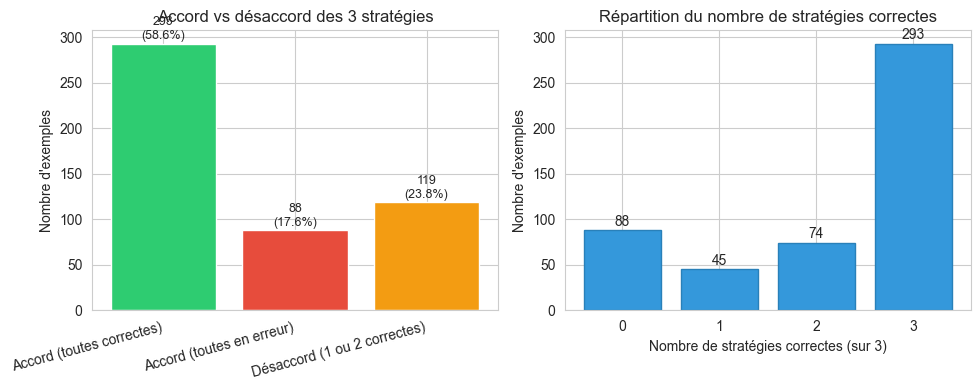

In [43]:
# Tableau et graphique : accord vs désaccord des 3 stratégies
acc_cols = [c for c in df_merged.columns if c.startswith('is_correct_')]
if len(acc_cols) < 2:
    print("Exécuter d'abord la cellule ci-dessus (3b) pour charger n_correct et les stratégies.")
else:
    df_merged['n_correct'] = df_merged[acc_cols].sum(axis=1)
    n_strat = len(acc_cols)
    n_total = len(df_merged)
    all_ok = (df_merged['n_correct'] == n_strat).sum()
    all_ko = (df_merged['n_correct'] == 0).sum()
    partiel = n_total - all_ok - all_ko
    # Tableau récapitulatif
    recap = pd.DataFrame({
        'Situation': [
            f'Accord : toutes correctes ({n_strat}/{n_strat})',
            f'Accord : toutes en erreur (0/{n_strat})',
            'Désaccord : 1 ou 2 stratégies correctes'
        ],
        'Effectif': [all_ok, all_ko, partiel],
        '%': [all_ok/n_total*100, all_ko/n_total*100, partiel/n_total*100]
    })
    display(recap)
    # Détail par nombre de stratégies correctes (0, 1, 2, 3)
    detail = df_merged['n_correct'].value_counts().sort_index()
    detail_pct = (detail / n_total * 100).round(1)
    detail_df = pd.DataFrame({'Effectif': detail, '%': detail_pct})
    detail_df.index.name = 'Nombre de stratégies correctes'
    print("Détail par nombre de stratégies correctes (par instance) :")
    display(detail_df)
    # Graphique en barres
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    # Gauche : accord / désaccord (3 catégories)
    ax = axes[0]
    cats = ['Accord (toutes correctes)', 'Accord (toutes en erreur)', 'Désaccord (1 ou 2 correctes)']
    vals = [all_ok, all_ko, partiel]
    colors_cat = ['#2ecc71', '#e74c3c', '#f39c12']
    bars = ax.bar(cats, vals, color=colors_cat)
    ax.set_xticklabels(cats, rotation=15, ha='right')
    ax.set_ylabel('Nombre d\'exemples')
    ax.set_title('Accord vs désaccord des 3 stratégies')
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 5, f'{v}\n({v/n_total*100:.1f}%)', ha='center', fontsize=9)
    # Droite : détail 0, 1, 2, 3 correctes
    ax = axes[1]
    x = detail.index.astype(int)
    ax.bar(x, detail.values, color='#3498db', edgecolor='#2980b9')
    ax.set_xticks(x)
    ax.set_xlabel('Nombre de stratégies correctes (sur 3)')
    ax.set_ylabel('Nombre d\'exemples')
    ax.set_title('Répartition du nombre de stratégies correctes')
    for i, (xi, v) in enumerate(zip(x, detail.values)):
        ax.text(xi, v + 5, f'{v}', ha='center', fontsize=10)
    plt.tight_layout()
    plt.show()


## 3c. Synthèse : quelle stratégie few-shot garder ?

Résumé pour décider : meilleur macro F1, robustesse (moins d'erreurs uniquement sur cette stratégie), et recouvrement des erreurs.

In [44]:
acc_cols = [c for c in df_merged.columns if c.startswith('is_correct_')]
names = [c.replace('is_correct_', '') for c in acc_cols]
if not acc_cols:
    print("Aucune colonne is_correct_* trouvée. Vérifier que les CSV Fewshot/Kate/Cosine ont bien été chargés (section 2).")
else:
    accs = [macro_f1_strategy(df_merged, n) for n in names]
    best_idx = np.argmax(accs)
    best_name = names[best_idx]
    print("Résumé comparaison des 3 stratégies few-shot (Prompt 1)")
    print("=" * 55)
    for i, n in enumerate(names):
        acc = accs[i]
        mark = " ← MEILLEURE" if i == best_idx else ""
        print(f"  {n:12s} : Macro F1 {acc:.2%}{mark}")
    print()
    print(f"Recommandation : stratégie **{best_name}** (macro F1 le plus élevé).")
    print("Vérifier aussi les sections 4–6 (performance par type/section/longueur) et")
    print("l'intersection des erreurs ci-dessus : si une stratégie a peu d'erreurs en commun avec les autres, elle peut être plus robuste.")

Résumé comparaison des 3 stratégies few-shot (Prompt 1)
  Fewshot      : Macro F1 71.72% ← MEILLEURE
  Kate         : Macro F1 71.24%
  Cosine       : Macro F1 70.86%

Recommandation : stratégie **Fewshot** (macro F1 le plus élevé).
Vérifier aussi les sections 4–6 (performance par type/section/longueur) et
l'intersection des erreurs ci-dessus : si une stratégie a peu d'erreurs en commun avec les autres, elle peut être plus robuste.


In [45]:
def extract_premise_hypothesis_from_user_content(text):
    """Extrait premise et hypothesis (statement) depuis le contenu user du JSONL."""
    if "HYPOTHESIS:" not in text:
        return text[:800] if len(text) > 800 else text, text[:500] if len(text) > 500 else text
    before_hyp, after_hyp = text.split("HYPOTHESIS:", 1)
    premise = before_hyp.replace("PREMISE:", "").strip()
    for sep in (".\n\nAnswer", "?\n\nAnswer", "? Answer", "\n\nAnswer"):
        if sep in after_hyp:
            after_hyp = after_hyp.split(sep)[0]
    statement = after_hyp.strip()
    return premise, statement

def _norm_bool(s):
    return s.apply(lambda x: str(x).strip().lower() == 'true') if s.dtype == object else s.astype(bool)

dfs = {}
if CSV_FEWSHOT:
    dfs['Fewshot'] = pd.read_csv(CSV_FEWSHOT)
    dfs['Fewshot']['is_correct'] = _norm_bool(dfs['Fewshot']['is_correct'])
if CSV_KATE:
    dfs['Kate'] = pd.read_csv(CSV_KATE)
    dfs['Kate']['is_correct'] = _norm_bool(dfs['Kate']['is_correct'])
if CSV_COSINE:
    dfs['Cosine'] = pd.read_csv(CSV_COSINE)
    dfs['Cosine']['is_correct'] = _norm_bool(dfs['Cosine']['is_correct'])

assert dfs, "Aucun CSV trouvé (Fewshot, Kate ou Cosine)."

metadata_list = []
with open(GOLD_TEST_JSONL, 'r', encoding='utf-8') as f:
    for idx, line in enumerate(f):
        if not line.strip():
            continue
        obj = json.loads(line)
        msgs = obj.get("messages", [])
        if len(msgs) < 2:
            continue
        # Few-shot : plusieurs user/assistant ; on prend le DERNIER user (question de test) et le dernier assistant (gold)
        user_content = ""
        label = ""
        for m in msgs:
            if m.get("role") == "user":
                user_content = m.get("content", "")
            elif m.get("role") == "assistant":
                label = m.get("content", "").strip()
        premise, statement = extract_premise_hypothesis_from_user_content(user_content)
        metadata_list.append({'index': idx, 'type': 'N/A', 'section_id': 'N/A', 'premise_jsonl': premise, 'statement': statement, 'label': label})

if GOLD_TEST_JSON.exists():
    with open(GOLD_TEST_JSON, 'r', encoding='utf-8') as f:
        gold_data = json.load(f)
    keys = list(gold_data.keys())
    if len(keys) == len(metadata_list):
        for i in range(len(metadata_list)):
            e = gold_data[keys[i]]
            metadata_list[i]['type'] = e.get('Type', 'N/A')
            metadata_list[i]['section_id'] = e.get('Section_id', 'N/A')

df_metadata = pd.DataFrame(metadata_list)

# Base = premier CSV dispo (Fewshot en priorité)
base_name = 'Fewshot' if 'Fewshot' in dfs else list(dfs.keys())[0]
df_merged = dfs[base_name][['index', 'true_label']].merge(df_metadata, on='index', how='left')
df_merged['premise'] = df_merged['premise_jsonl'].astype(str)
df_merged['hypothesis'] = df_merged['statement'].astype(str)
for name, d in dfs.items():
    pred_col = f'pred_{name}'
    correct_col = f'is_correct_{name}'
    df_merged = df_merged.merge(d[['index', 'predicted_label', 'is_correct']].rename(columns={'predicted_label': pred_col, 'is_correct': correct_col}), on='index', how='left')

# Compatibilité avec les sections suivantes : is_correct / predicted_label = première stratégie
acc_cols = [c for c in df_merged.columns if c.startswith('is_correct_')]
if acc_cols:
    df_merged['is_correct'] = df_merged[acc_cols[0]]
    first_name = acc_cols[0].replace('is_correct_', '')
    df_merged['predicted_label'] = df_merged.get(f'pred_{first_name}', df_merged['true_label'])

def safe_len(s):
    return len(str(s)) if pd.notna(s) else 0
df_merged['premise_len'] = df_merged['premise'].apply(safe_len)
df_merged['hypothesis_len'] = df_merged['hypothesis'].apply(safe_len)
df_merged['prompt_len'] = df_merged['premise_len'] + df_merged['hypothesis_len']

def safe_length_bin(series):
    q = series.quantile([0, 1/3, 2/3, 1])
    edges = np.sort(q.unique())
    n_bins = max(1, len(edges) - 1)
    if n_bins == 1:
        return pd.Series('Moyen', index=series.index)
    labels = ['Court', 'Moyen', 'Long'][:n_bins]
    return pd.cut(series, bins=edges, labels=labels, include_lowest=True)
df_merged['length_bin'] = safe_length_bin(df_merged['prompt_len'])

print("Exemples :", len(df_merged))
print("Stratégies chargées :", [k for k in dfs])
print("Métadonnées (type, section) :", df_metadata['type'].notna().all() and (df_metadata['section_id'] != 'N/A').all())


Exemples : 500
Stratégies chargées : ['Fewshot', 'Kate', 'Cosine']
Métadonnées (type, section) : True


## 3. Statistiques globales


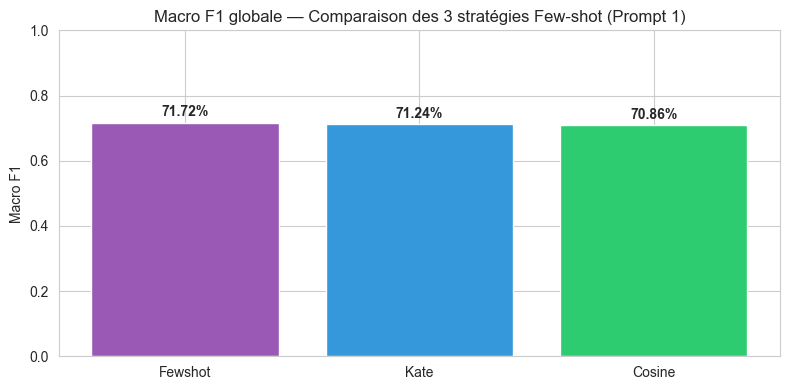

,Macro F1
Fewshot,0.717172
Kate,0.712425
Cosine,0.708572


In [46]:
acc_cols = [c for c in df_merged.columns if c.startswith('is_correct_')]
strategy_names = [c.replace('is_correct_', '') for c in acc_cols]
scores = {name: macro_f1_strategy(df_merged, name) for name in strategy_names}
names = list(scores.keys())
accs = list(scores.values())
colors = ['#9b59b6', '#3498db', '#2ecc71'][:len(names)]
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(names, accs, color=colors)
ax.set_ylabel('Macro F1')
ax.set_ylim(0, 1)
ax.set_title('Macro F1 globale — Comparaison des 3 stratégies Few-shot (Prompt 1)')
for bar, a in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, a + 0.02, f'{a:.2%}', ha='center', fontweight='bold')
plt.tight_layout()
fig.savefig(FIGURES_DIR / '01_macro_f1_comparison_3strategies.png', dpi=150, bbox_inches='tight')
plt.show()
pd.DataFrame([scores]).T.rename(columns={0: 'Macro F1'})


## 4. Analyse par type de tâche (Single vs Comparison)


/var/folders/71/b1s1b9y50596_3t1fgw_1dzw0000gn/T/ipykernel_94192/1021943008.py:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(group_cols).apply(_f1_group)


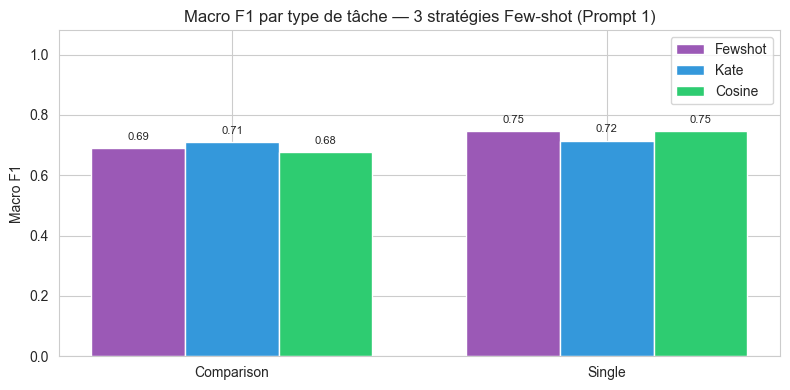

,Fewshot,Kate,Cosine
type,,,
Comparison,0.691669,0.710089,0.675984
Single,0.745906,0.715092,0.746333


In [47]:
acc_cols = [c for c in df_merged.columns if c.startswith('is_correct_')]
strategy_names = [c.replace('is_correct_', '') for c in acc_cols]
colors = ['#9b59b6', '#3498db', '#2ecc71'][:len(strategy_names)]

acc_by_type = macro_f1_by_group(df_merged, 'type', acc_cols)
n_cat = len(acc_by_type.index)
width = 0.25
x = np.arange(n_cat)
fig, ax = plt.subplots(figsize=(8, 4))
for i, name in enumerate(strategy_names):
    offset = (i - len(strategy_names)/2 + 0.5) * width
    x_pos = x + offset
    ax.bar(x_pos, acc_by_type[name], width, label=name, color=colors[i])
    for j, v in enumerate(acc_by_type[name]):
        if pd.notna(v):
            ax.text(x_pos[j], v + 0.02, f'{v:.2f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(acc_by_type.index)
ax.set_ylabel('Macro F1')
ax.set_ylim(0, 1.08)
ax.legend()
ax.set_title('Macro F1 par type de tâche — 3 stratégies Few-shot (Prompt 1)')
plt.tight_layout()
fig.savefig(FIGURES_DIR / '02_macro_f1_par_type.png', dpi=150, bbox_inches='tight')
plt.show()
display(acc_by_type)


## 5. Analyse par section du protocole


/var/folders/71/b1s1b9y50596_3t1fgw_1dzw0000gn/T/ipykernel_94192/1021943008.py:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(group_cols).apply(_f1_group)


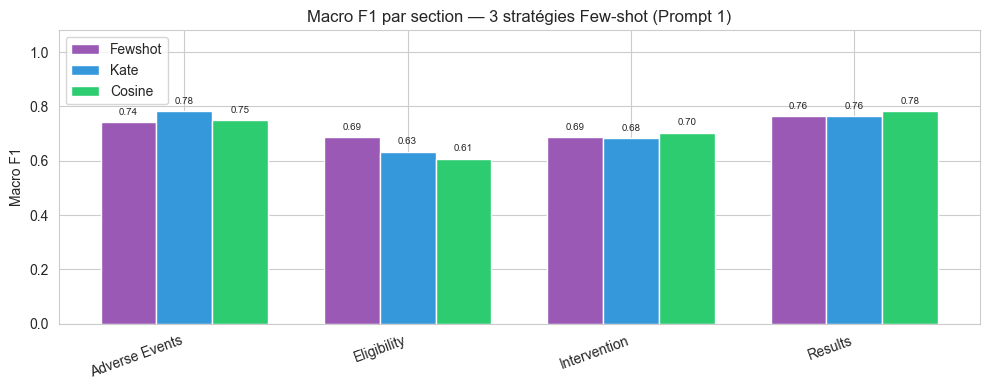

,Fewshot,Kate,Cosine
section_id,,,
Adverse Events,0.741217,0.783273,0.749722
Eligibility,0.686610,0.632791,0.608262
Intervention,0.687099,0.682705,0.703696
Results,0.763118,0.763118,0.783000


In [48]:
acc_by_sec = macro_f1_by_group(df_merged, 'section_id', acc_cols)
n_cat = len(acc_by_sec.index)
x = np.arange(n_cat)
fig, ax = plt.subplots(figsize=(10, 4))
for i, name in enumerate(strategy_names):
    offset = (i - len(strategy_names)/2 + 0.5) * width
    x_pos = x + offset
    ax.bar(x_pos, acc_by_sec[name], width, label=name, color=colors[i])
    for j, v in enumerate(acc_by_sec[name]):
        if pd.notna(v):
            ax.text(x_pos[j], v + 0.02, f'{v:.2f}', ha='center', va='bottom', fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels(acc_by_sec.index, rotation=20, ha='right')
ax.set_ylabel('Macro F1')
ax.set_ylim(0, 1.08)
ax.legend()
ax.set_title('Macro F1 par section — 3 stratégies Few-shot (Prompt 1)')
plt.tight_layout()
fig.savefig(FIGURES_DIR / '03_macro_f1_par_section.png', dpi=150, bbox_inches='tight')
plt.show()
display(acc_by_sec)


### 5b. Synthèse : performance par type ET par section (un seul graphique)

Un seul graphique pour justifier le choix de stratégie : **2 panneaux** (Single | Comparison), avec les **sections** en abscisse et les **3 modèles** en barres groupées.


/var/folders/71/b1s1b9y50596_3t1fgw_1dzw0000gn/T/ipykernel_94192/1021943008.py:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(group_cols).apply(_f1_group)


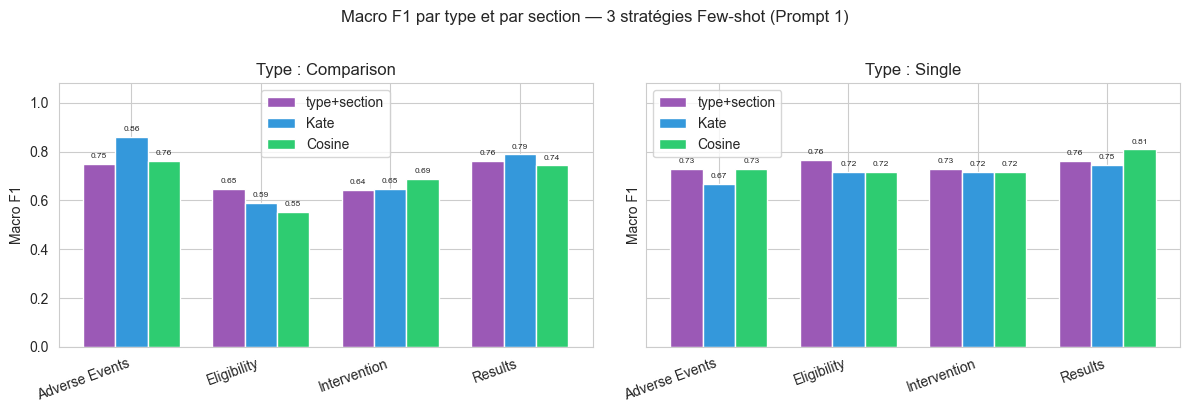

Fewshot      Kate    Cosine
type       section_id                                  
Comparison Adverse Events  0.748252  0.861004  0.763478
           Eligibility     0.647436  0.590371  0.553419
           Intervention    0.642105  0.646753  0.689498
           Results         0.761111  0.788871  0.743631
Single     Adverse Events  0.729049  0.666667  0.729049
           Eligibility     0.764957  0.717949  0.717949
           Intervention    0.727941  0.715749  0.716164
           Results         0.761905  0.745455  0.809476

In [49]:
acc_type_sec = macro_f1_by_group(df_merged, ['type', 'section_id'], acc_cols)
types = acc_type_sec.index.get_level_values('type').unique().tolist()
sections = acc_type_sec.index.get_level_values('section_id').unique().tolist()
n_sec = len(sections)
width = 0.25
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for idx, t in enumerate(types):
    ax = axes[idx]
    data = acc_type_sec.xs(t, level='type')
    data = data.reindex(sections)
    x = np.arange(n_sec)
    legend_labels = {'Fewshot': 'type+section', 'Kate': 'Kate', 'Cosine': 'Cosine'}
    for i, name in enumerate(strategy_names):
        offset = (i - len(strategy_names)/2 + 0.5) * width
        x_pos = x + offset
        ax.bar(x_pos, data[name], width, label=legend_labels.get(name, name), color=colors[i])
        for j, v in enumerate(data[name]):
            if pd.notna(v):
                ax.text(x_pos[j], v + 0.02, f'{v:.2f}', ha='center', va='bottom', fontsize=6)
    ax.set_xticks(x)
    ax.set_xticklabels(sections, rotation=20, ha='right')
    ax.set_ylabel('Macro F1')
    ax.set_ylim(0, 1.08)
    ax.legend()
    ax.set_title(f'Type : {t}')
fig.suptitle('Macro F1 par type et par section — 3 stratégies Few-shot (Prompt 1)', fontsize=12, y=1.02)
plt.tight_layout()
fig.savefig(FIGURES_DIR / '02b_macro_f1_type_et_section.png', dpi=150, bbox_inches='tight')
plt.show()
display(acc_type_sec)


## 6. Analyse par longueur du prompt (court / moyen / long)

On regarde si les modèles se trompent davantage sur les **prompts longs** (prémisse + hypothèse plus longues) ou **courts**.


/var/folders/71/b1s1b9y50596_3t1fgw_1dzw0000gn/T/ipykernel_94192/1021943008.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return df.groupby(group_cols).apply(_f1_group)
/var/folders/71/b1s1b9y50596_3t1fgw_1dzw0000gn/T/ipykernel_94192/1021943008.py:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(group_cols).apply(_f1_group)


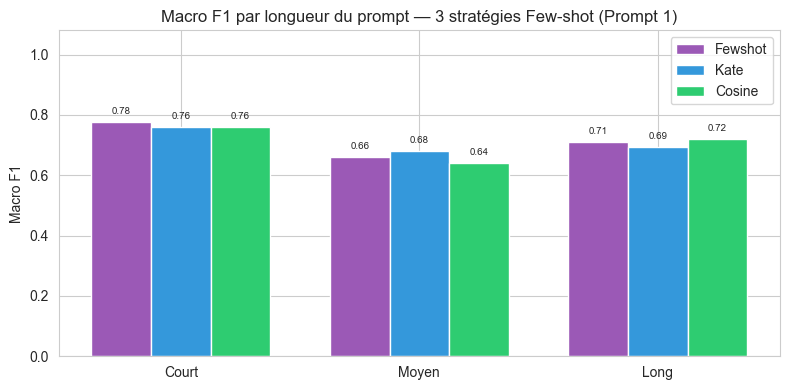

,Fewshot,Kate,Cosine
length_bin,,,
Court,0.776875,0.760264,0.760470
Moyen,0.661865,0.679782,0.641652
Long,0.710422,0.694810,0.720939


Effectifs par bin:
length_bin
Court    167
Moyen    166
Long     167
dtype: int64


/var/folders/71/b1s1b9y50596_3t1fgw_1dzw0000gn/T/ipykernel_94192/4275681942.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_merged.groupby('length_bin').size())


In [50]:
acc_by_len = macro_f1_by_group(df_merged, 'length_bin', acc_cols)
n_cat = len(acc_by_len.index)
x = np.arange(n_cat)
fig, ax = plt.subplots(figsize=(8, 4))
for i, name in enumerate(strategy_names):
    offset = (i - len(strategy_names)/2 + 0.5) * width
    x_pos = x + offset
    ax.bar(x_pos, acc_by_len[name], width, label=name, color=colors[i])
    for j, v in enumerate(acc_by_len[name]):
        if pd.notna(v):
            ax.text(x_pos[j], v + 0.02, f'{v:.2f}', ha='center', va='bottom', fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels(acc_by_len.index)
ax.set_ylabel('Macro F1')
ax.set_ylim(0, 1.08)
ax.legend()
ax.set_title('Macro F1 par longueur du prompt — 3 stratégies Few-shot (Prompt 1)')
plt.tight_layout()
fig.savefig(FIGURES_DIR / '04_macro_f1_par_longueur.png', dpi=150, bbox_inches='tight')
plt.show()
display(acc_by_len)
print("Effectifs par bin:")
print(df_merged.groupby('length_bin').size())


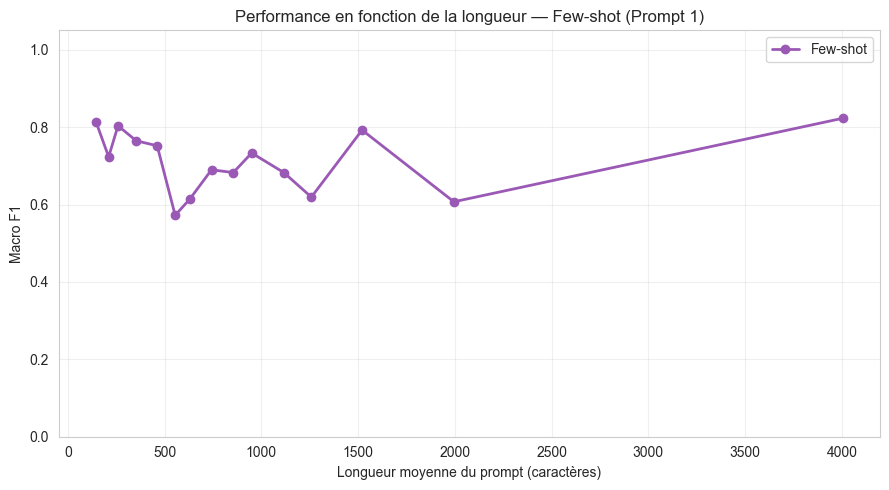

In [51]:
# Courbe : performance (macro F1) en fonction de la longueur du prompt
# Bins par *rang* de longueur (percentile) pour avoir toujours N_BINS points, même si les longueurs varient peu
N_BINS = 15
for df in [df_merged]:
    df['len_bin_idx'] = (df['prompt_len'].rank(pct=True, method='first') * N_BINS).astype(int).clip(0, N_BINS - 1)

first_strat = [c.replace('is_correct_', '') for c in df_merged.columns if c.startswith('is_correct_')][0]

def macro_f1_vs_length(df, strategy_name):
    out = []
    for idx, g in df.groupby('len_bin_idx'):
        if len(g) < 1:
            continue
        out.append({'len_bin_idx': idx, 'len_moy': g['prompt_len'].mean(), 'n': len(g), 'macro_f1': macro_f1_strategy(g, strategy_name)})
    return pd.DataFrame(out).sort_values('len_bin_idx')

curve = macro_f1_vs_length(df_merged, first_strat)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(curve['len_moy'], curve['macro_f1'], 'o-', color='#9b59b6', label='Few-shot', linewidth=2, markersize=6)
ax.set_xlabel('Longueur moyenne du prompt (caractères)')
ax.set_ylabel('Macro F1')
ax.set_ylim(0, 1.05)
ax.legend()
ax.set_title('Performance en fonction de la longueur — Few-shot (Prompt 1)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(FIGURES_DIR / '04b_macro_f1_vs_longueur_courbe.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Quand le modèle se trompe

Distribution des **erreurs** : par type, section, longueur ; et type d'erreur (Entailment prédit Contradiction ou l'inverse).


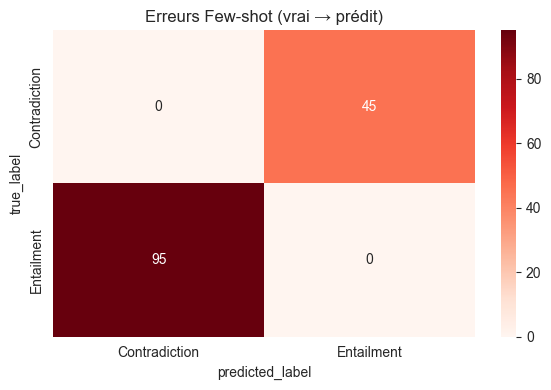

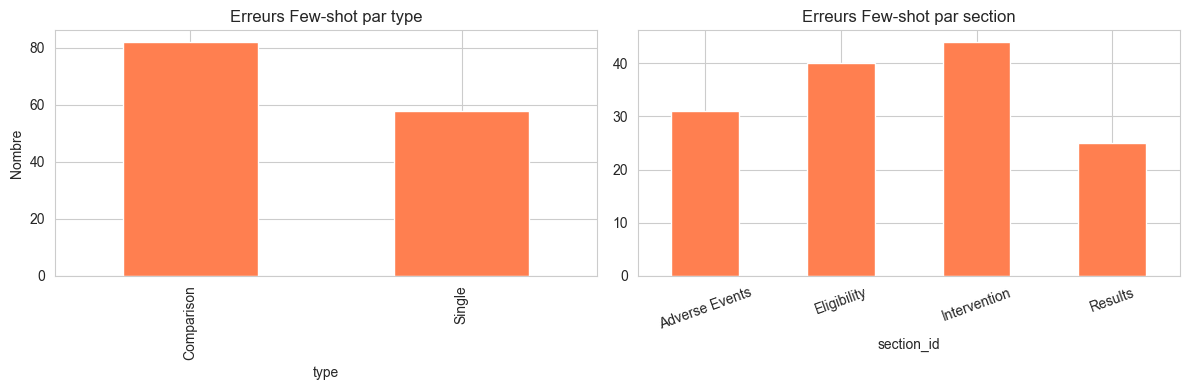

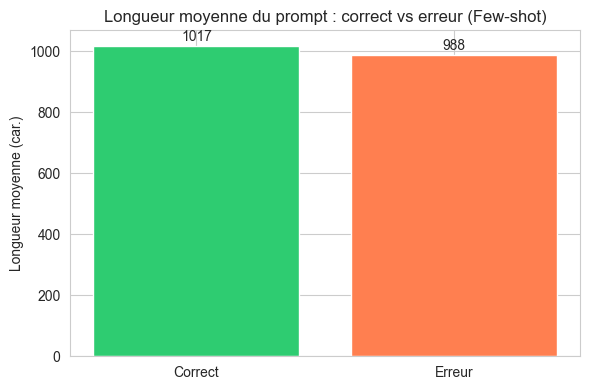

In [52]:
err = df_merged[~df_merged['is_correct']]
fig, ax = plt.subplots(figsize=(6, 4))
if len(err) > 0:
    c = err.groupby('true_label')['predicted_label'].value_counts().unstack(fill_value=0)
    sns.heatmap(c, annot=True, fmt='d', cmap='Reds', ax=ax)
ax.set_title('Erreurs Few-shot (vrai → prédit)')
plt.tight_layout()
fig.savefig(FIGURES_DIR / '05_erreurs_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
if len(err) > 0:
    err.groupby('type').size().plot(kind='bar', ax=axes[0], color='coral')
    axes[0].set_title('Erreurs Few-shot par type')
    axes[0].set_ylabel('Nombre')
    err.groupby('section_id').size().plot(kind='bar', ax=axes[1], color='coral')
    axes[1].set_title('Erreurs Few-shot par section')
    axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
fig.savefig(FIGURES_DIR / '06_erreurs_par_type_et_section.png', dpi=150, bbox_inches='tight')
plt.show()

correct_len = df_merged[df_merged['is_correct']]['prompt_len'].mean()
wrong_len = df_merged[~df_merged['is_correct']]['prompt_len'].mean()
fig, ax = plt.subplots(figsize=(6, 4))
vals_07 = [correct_len, wrong_len]
ax.bar(['Correct', 'Erreur'], vals_07, color=['#2ecc71', 'coral'])
for i, v in enumerate(vals_07): ax.text(i, v + 5, f'{v:.0f}', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Longueur moyenne (car.)')
ax.set_title('Longueur moyenne du prompt : correct vs erreur (Few-shot)')
plt.tight_layout()
fig.savefig(FIGURES_DIR / '07_longueur_erreurs_vs_corrects.png', dpi=150, bbox_inches='tight')
plt.show()


### 7b. Cas où le modèle n'a pas produit un label reconnu (UNKNOWN)

Quand le script d'évaluation ne trouve ni "Entailment" ni "Contradiction" dans les 50 premiers caractères de la sortie, le label est marqué **UNKNOWN**. Ci-dessous : les exemples concernés avec la sortie brute du modèle pour analyser le problème.

In [53]:
unknown = df_merged[df_merged['predicted_label'] == 'UNKNOWN']
print(f"Few-shot : {len(unknown)} cas UNKNOWN")
if len(unknown) > 0:
    cols = ['index', 'true_label', 'type', 'section_id']
    if 'raw_generated' in unknown.columns:
        cols.append('raw_generated')
    display_df = unknown[cols].copy()
    if 'raw_generated' in unknown.columns:
        display_df['raw_generated'] = display_df['raw_generated'].str[:200] + ('...' if display_df['raw_generated'].str.len().gt(200).any() else '')
    display(display_df)
    unknown[['index', 'true_label', 'type', 'section_id', 'premise', 'hypothesis']].assign(raw=unknown['raw_generated']).to_csv(FIGURES_DIR / 'cas_unknown.csv', index=False)
    print(f"\n>>> Cas UNKNOWN exportés : {FIGURES_DIR / 'cas_unknown.csv'}")
else:
    print("Aucun cas UNKNOWN.")

Few-shot : 0 cas UNKNOWN
Aucun cas UNKNOWN.


## 8. Répartition correct / erreur

Nombre d'exemples corrects vs en erreur pour le modèle few-shot.


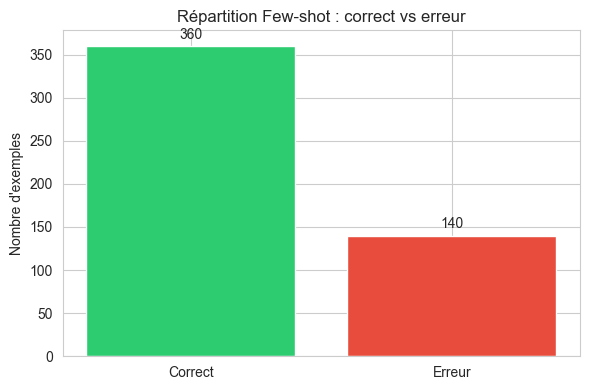

Sections (macro F1 décroissant) :
                  n   Fewshot
section_id                   
Results         106  0.763118
Adverse Events  120  0.741217
Intervention    142  0.687099
Eligibility     132  0.686610


/var/folders/71/b1s1b9y50596_3t1fgw_1dzw0000gn/T/ipykernel_94192/1021943008.py:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(group_cols).apply(_f1_group)


In [54]:
n_correct = df_merged['is_correct'].sum()
n_wrong = (~df_merged['is_correct']).sum()
fig, ax = plt.subplots(figsize=(6, 4))
vals_08 = [n_correct, n_wrong]
ax.bar(['Correct', 'Erreur'], vals_08, color=['#2ecc71', '#e74c3c'])
for i, v in enumerate(vals_08): ax.text(i, v + 5, str(int(v)), ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Nombre d\'exemples')
ax.set_title('Répartition Few-shot : correct vs erreur')
plt.tight_layout()
fig.savefig(FIGURES_DIR / '08_correct_vs_erreur.png', dpi=150, bbox_inches='tight')
plt.show()
# Tableau sections par macro F1 (première stratégie)
acc_cols = [c for c in df_merged.columns if c.startswith('is_correct_')]
acc_by_sec = macro_f1_by_group(df_merged, 'section_id', acc_cols) if acc_cols else pd.DataFrame()
if not acc_by_sec.empty:
    acc_sec = acc_by_sec.copy()
    acc_sec['n'] = df_merged.groupby('section_id').size().values
    first_col = acc_by_sec.columns[0]
    print('Sections (macro F1 décroissant) :')
    print(acc_sec.sort_values(first_col, ascending=False)[['n', first_col]])


## 9. Régressions / Améliorations

N/A : un seul modèle (few-shot), pas de comparaison baseline vs finetuné.


In [55]:
# Un seul modèle (few-shot) : pas de régressions/améliorations à calculer
print("N/A — un seul modèle (few-shot).")


N/A — un seul modèle (few-shot).


## 10. Améliorations

N/A (un seul modèle).


In [56]:
print("N/A — un seul modèle (few-shot).")


N/A — un seul modèle (few-shot).


## 11. Exemples d'erreurs

Quelques exemples où le modèle few-shot s'est trompé.


In [57]:
N_EX = 5
err_ex = df_merged[~df_merged['is_correct']]
print(f'Exemples d\'erreurs (Few-shot s\'est trompé) — {min(N_EX, len(err_ex))} premiers :')
for _, row in err_ex.head(N_EX).iterrows():
    print(f"  Index {row['index']} | Type: {row['type']} | Section: {row['section_id']} | Vrai: {row['true_label']} | Prédit: {row['predicted_label']}")
    print(f"    Statement: {str(row.get('statement', row.get('hypothesis', '')))[:120]}...")


Exemples d'erreurs (Few-shot s'est trompé) — 5 premiers :
  Index 2 | Type: Comparison | Section: Eligibility | Vrai: Entailment | Prédit: Contradiction
    Statement: the secondary trial requires patients to be over a certain age, but the primary trial does not specify an age range for ...
  Index 5 | Type: Comparison | Section: Adverse Events | Vrai: Entailment | Prédit: Contradiction
    Statement: There are no cases of anorexia, hypothermia or hallucinations recorded in the Aes of the primary trial or the secondary ...
  Index 7 | Type: Comparison | Section: Eligibility | Vrai: Contradiction | Prédit: Entailment
    Statement: Any patients with Documented allergy to cephalosporin or trimethoprim/sulfamethoxazole will not be eligible for the seco...
  Index 13 | Type: Single | Section: Intervention | Vrai: Contradiction | Prédit: Entailment
    Statement: Cohort A and B of the primary trial are administered the same Three electroporation injections of LD V934...
  Index 35 | Type: S

## 12. Synthèse pour le rapport

Résumé rédigé : **dans quels cas le modèle se trompe** et **dans quels cas il est très bon**. Le fichier est sauvegardé dans le dossier figures pour inclusion au rapport.

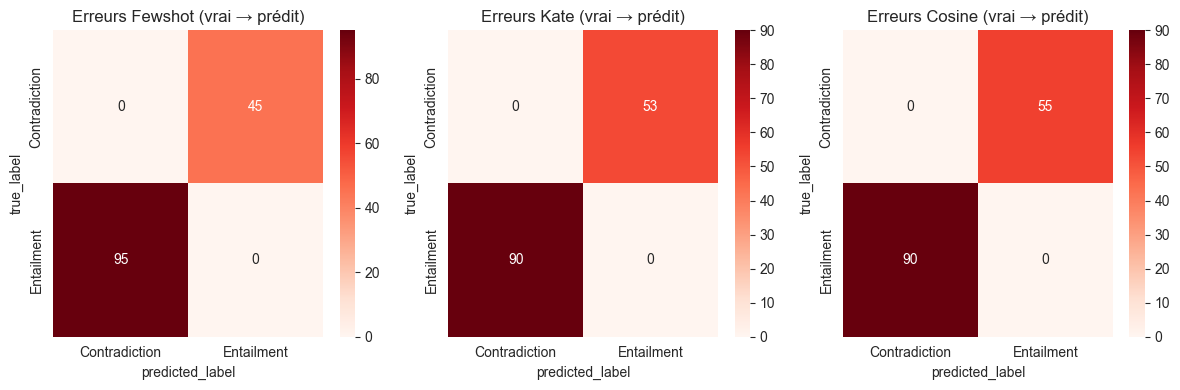

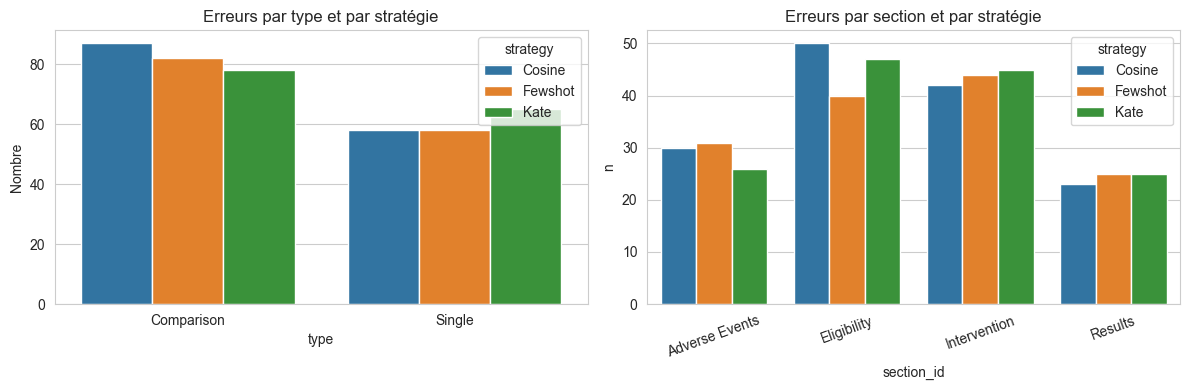

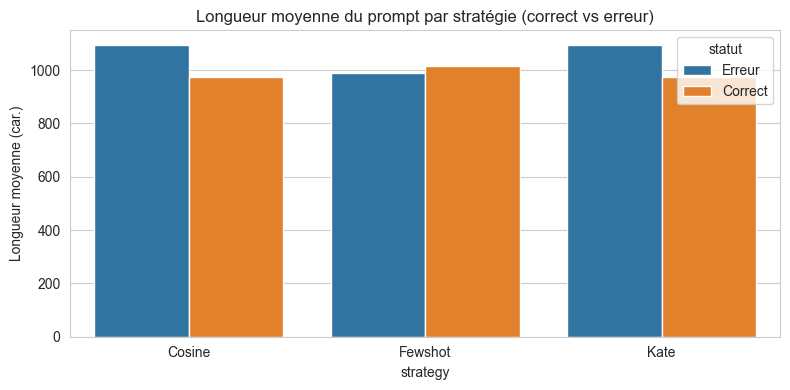

In [58]:
# 7. Erreurs des trois stratégies few-shot (comparaison)
# On part des colonnes is_correct_* et pred_* dans df_merged pour reconstruire un df "long" avec une colonne strategy.

acc_cols = [c for c in df_merged.columns if c.startswith('is_correct_')]
strategy_names = [c.replace('is_correct_', '') for c in acc_cols]

rows = []
for name, col in zip(strategy_names, acc_cols):
    mask = ~df_merged[col]  # erreurs pour cette stratégie
    sub = df_merged.loc[mask, ['index', 'true_label', 'type', 'section_id', 'prompt_len']].copy()
    sub['strategy'] = name
    pred_col = f'pred_{name}'
    if pred_col in df_merged.columns:
        sub['predicted_label'] = df_merged.loc[mask, pred_col].values
    else:
        sub['predicted_label'] = df_merged.loc[mask, 'predicted_label'].values
    rows.append(sub)

err = pd.concat(rows, ignore_index=True)

# 1) Matrices de confusion : une par stratégie
fig, axes = plt.subplots(1, len(strategy_names), figsize=(4 * len(strategy_names), 4))
axes = np.atleast_1d(axes)

for ax, st in zip(axes, strategy_names):
    sub = err[err['strategy'] == st]
    if len(sub) > 0:
        c = sub.groupby('true_label')['predicted_label'].value_counts().unstack(fill_value=0)
        sns.heatmap(c, annot=True, fmt='d', cmap='Reds', ax=ax)
    ax.set_title(f'Erreurs {st} (vrai → prédit)')

plt.tight_layout()
fig.savefig(FIGURES_DIR / '05_erreurs_confusion_3strategies.png', dpi=150, bbox_inches='tight')
plt.show()

# 2) Erreurs par type / par section : 3 barres par groupe
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if len(err) > 0:
    tab_type = (
        err
        .groupby(['type', 'strategy'])
        .size()
        .reset_index(name='n')
    )
    sns.barplot(data=tab_type, x='type', y='n', hue='strategy', ax=axes[0])
    axes[0].set_title('Erreurs par type et par stratégie')
    axes[0].set_ylabel('Nombre')

    tab_sec = (
        err
        .groupby(['section_id', 'strategy'])
        .size()
        .reset_index(name='n')
    )
    sns.barplot(data=tab_sec, x='section_id', y='n', hue='strategy', ax=axes[1])
    axes[1].set_title('Erreurs par section et par stratégie')
    axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
fig.savefig(FIGURES_DIR / '06_erreurs_par_type_et_section_3strategies.png', dpi=150, bbox_inches='tight')
plt.show()

# 3) Longueur moyenne du prompt : correct vs erreur pour chaque stratégie
long_rows = []
for name, col in zip(strategy_names, acc_cols):
    tmp = pd.DataFrame({
        'strategy': name,
        'is_correct': df_merged[col].values,
        'prompt_len': df_merged['prompt_len'].values,
    })
    long_rows.append(tmp)

g = (
    pd.concat(long_rows, ignore_index=True)
    .groupby(['strategy', 'is_correct'])['prompt_len']
    .mean()
    .reset_index()
)
g['statut'] = np.where(g['is_correct'], 'Correct', 'Erreur')

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=g, x='strategy', y='prompt_len', hue='statut', ax=ax)
ax.set_ylabel('Longueur moyenne (car.)')
ax.set_title('Longueur moyenne du prompt par stratégie (correct vs erreur)')
plt.tight_layout()
fig.savefig(FIGURES_DIR / '07_longueur_erreurs_vs_corrects_3strategies.png', dpi=150, bbox_inches='tight')
plt.show()

In [59]:
# Synthèse : quand le modèle few-shot se trompe vs quand il est très bon
err_syn = df_merged[~df_merged['is_correct']]
correct_syn = df_merged[df_merged['is_correct']]
# Reconstruire acc_sec si besoin (pour le résumé macro F1)
if 'acc_by_sec' in dir() and not acc_by_sec.empty:
    acc_sec = acc_by_sec.copy()
    acc_sec['n'] = df_merged.groupby('section_id').size().values
else:
    acc_sec = pd.DataFrame()

lines = [
    f"# Synthèse analyse d'erreurs — Few-shot (Prompt 1)",
    "",
    "## Dans quels cas le modèle se trompe le plus",
    f"- Sections les plus difficiles : {err_syn.groupby('section_id').size().sort_values(ascending=False).head(3).to_dict()}",
    f"- Types les plus difficiles : {err_syn.groupby('type').size().sort_values(ascending=False).to_dict()}",
    f"- Longueur moyenne du prompt (car.) pour les erreurs : {err_syn['prompt_len'].mean():.0f}",
    f"- Longueur moyenne pour les corrects : {correct_syn['prompt_len'].mean():.0f}",
    "",
    "## Dans quels cas le modèle est très bon",
    f"- Sections avec le meilleur macro F1 : {acc_sec.nlargest(3, acc_sec.columns[0])[acc_sec.columns[0]].to_dict() if not acc_sec.empty else {}}",
    f"- Types avec le meilleur macro F1 : {acc_by_type[acc_by_type.columns[0]].to_dict() if not acc_by_type.empty else {}}",
    f"- Bins de longueur (macro F1) : {acc_by_len[acc_by_len.columns[0]].to_dict() if not acc_by_len.empty else {}}",
    f"- Nombre de prédictions correctes : {df_merged['is_correct'].sum()}",
]
synthese_path = FIGURES_DIR / "synthese_erreurs_fewshot.txt"
synthese_path.write_text("\n".join(lines), encoding="utf-8")
print("\n".join(lines))
print(f"\n>>> Synthèse sauvegardée : {synthese_path}")

# Synthèse analyse d'erreurs — Few-shot (Prompt 1)

## Dans quels cas le modèle se trompe le plus
- Sections les plus difficiles : {'Intervention': 44, 'Eligibility': 40, 'Adverse Events': 31}
- Types les plus difficiles : {'Comparison': 82, 'Single': 58}
- Longueur moyenne du prompt (car.) pour les erreurs : 988
- Longueur moyenne pour les corrects : 1017

## Dans quels cas le modèle est très bon
- Sections avec le meilleur macro F1 : {'Results': 0.7631179047108251, 'Adverse Events': 0.7412173913043478, 'Intervention': 0.687099358974359}
- Types avec le meilleur macro F1 : {'Comparison': 0.6916694416694417, 'Single': 0.7459060299969391}
- Bins de longueur (macro F1) : {'Court': 0.7768750225688802, 'Moyen': 0.6618652698966971, 'Long': 0.7104224312857406}
- Nombre de prédictions correctes : 360

>>> Synthèse sauvegardée : /Users/lubin/Documents/NLI_Finetuning/NLI4CT/results/Fewshot/figures/synthese_erreurs_fewshot.txt


## 13. Export des résultats détaillés


In [60]:
df_export = df_merged[['index', 'premise', 'hypothesis', 'true_label', 'predicted_label', 'is_correct', 'premise_len', 'hypothesis_len', 'prompt_len', 'length_bin', 'type', 'section_id']].copy()
out_csv = RESULTS_DIR / 'error_analysis_detailed_fewshot_prompt1.csv'
df_export.to_csv(out_csv, index=False)
print(f'Résultats détaillés sauvegardés : {out_csv}')
print(f'Figures sauvegardées dans : {FIGURES_DIR}')


NameError: name 'RESULTS_DIR' is not defined